# Lab 10 — problem trzech ciał

Notebook rozwiązuje zadanie z równań różniczkowych zwyczajnych:

- jawna metoda Eulera,
- niejawna metoda Eulera,
- półjawna metoda Eulera,
- metoda Rungego–Kutty 4. rzędu (RK4),
- punkty libracyjne Lagrange’a,
- trajektoria w układzie synodycznym i inercjalnym,
- prędkość w układzie inercjalnym,
- energie \(T\), \(U\),
- całka Jacobiego \(C\).

W kodzie przyjęto wektor stanu w kolejności:
Y = [x, y, u, v].


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import root

# Parametry z treści zadania
mu = 0.012150582
t0, t_end = 0.0, 5.0

# Wektor stanu: Y = [x, y, u, v]
Y0 = np.array([1.05, 0.1, -0.45, -0.25], dtype=float)

# Liczba kroków.
# N = 5000 daje h = 0.001 i jest rozsądnym kompromisem między dokładnością a czasem działania.
N = 5000
t = np.linspace(t0, t_end, N + 1)
h = t[1] - t[0]

print(f"h = {h}, liczba kroków = {N}")

h = 0.001, liczba kroków = 5000


In [2]:
def distances(Y, mu=mu):
    """
    Odległości od Ziemi i Księżyca.
    Y może być wektorem kształtu (4,) albo tablicą kształtu (n, 4).
    """
    Y = np.asarray(Y)
    x = Y[..., 0]
    y = Y[..., 1]
    r1 = np.hypot(x + mu, y)
    r2 = np.hypot(x - 1 + mu, y)
    return r1, r2


def rhs(t, Y, mu=mu):
    """
    Prawa strona układu.
    Wektor stanu: Y = [x, y, u, v].
    """
    x, y, u, v = Y
    r1, r2 = distances(Y, mu)

    du = x + 2*v - ((1 - mu)*(x + mu)/r1**3 + mu*(x - 1 + mu)/r2**3)
    dv = y - 2*u - ((1 - mu)*y/r1**3 + mu*y/r2**3)

    return np.array([u, v, du, dv], dtype=float)


def kinetic_energy(Y):
    """Energia kinetyczna T = 1/2(u^2 + v^2)."""
    u = Y[..., 2]
    v = Y[..., 3]
    return 0.5 * (u**2 + v**2)


def potential_energy(Y, mu=mu):
    """Energia potencjalna U z treści zadania."""
    x = Y[..., 0]
    y = Y[..., 1]
    r1, r2 = distances(Y, mu)
    return 0.5 * (x**2 + y**2) + (1 - mu)/r1 + mu/r2


def jacobi_constant(Y, mu=mu):
    """Całka Jacobiego C z treści zadania."""
    x = Y[..., 0]
    y = Y[..., 1]
    u = Y[..., 2]
    v = Y[..., 3]
    r1, r2 = distances(Y, mu)
    return x**2 + y**2 + 2*(1 - mu)/r1 + 2*mu/r2 - u**2 - v**2

In [3]:
def explicit_euler(f, Y0, t):
    """Jawna metoda Eulera."""
    Y = np.empty((len(t), len(Y0)))
    Y[0] = Y0

    for k in range(len(t) - 1):
        hk = t[k + 1] - t[k]
        Y[k + 1] = Y[k] + hk * f(t[k], Y[k])

    return Y


def implicit_euler(f, Y0, t, tol=1e-10):
    """
    Niejawna metoda Eulera:
        Y_{k+1} = Y_k + h f(t_{k+1}, Y_{k+1})

    W każdym kroku rozwiązujemy układ nieliniowy metodą root.
    Dla stabilności jako start Newtona bierzemy predyktor z jawnego Eulera.
    """
    Y = np.empty((len(t), len(Y0)))
    Y[0] = Y0

    residual_norms = np.empty(len(t) - 1)
    failed_steps = []

    for k in range(len(t) - 1):
        hk = t[k + 1] - t[k]
        tk1 = t[k + 1]
        Yk = Y[k]

        predictor = Yk + hk * f(t[k], Yk)

        def F(Z):
            return Z - Yk - hk * f(tk1, Z)

        sol = root(F, predictor, method="hybr", tol=tol)
        residual = np.linalg.norm(F(sol.x), ord=np.inf)

        # Awaryjnie próbujemy metody Levenberga-Marquardta,
        # gdy klasyczny hybr nie domknie residualu.
        if (not sol.success) or residual > 1e-8:
            sol2 = root(
                F,
                Yk,
                method="lm",
                options={"ftol": tol, "xtol": tol, "gtol": tol, "maxiter": 200},
            )
            residual2 = np.linalg.norm(F(sol2.x), ord=np.inf)
            if residual2 < residual:
                sol = sol2
                residual = residual2

        if residual > 1e-6:
            failed_steps.append((k, t[k], residual))

        Y[k + 1] = sol.x
        residual_norms[k] = residual

    if failed_steps:
        print("Uwaga: niektóre kroki niejawnego Eulera mają duży residual.")
        print("Pierwsze 5 problematycznych kroków:", failed_steps[:5])
    else:
        print(f"Niejawny Euler: OK, max residual = {residual_norms.max():.3e}")

    return Y


def semi_implicit_euler(Y0, t, mu=mu):
    """
    Półjawna metoda Eulera w wariancie Euler-Cromer.

    Najpierw aktualizujemy prędkości, traktując człony Coriolisa półjawnie:
        u_{n+1} = u_n + h [x_n + 2 v_{n+1} - g_x(x_n, y_n)]
        v_{n+1} = v_n + h [y_n - 2 u_{n+1} - g_y(x_n, y_n)]

    Potem aktualizujemy położenia:
        x_{n+1} = x_n + h u_{n+1}
        y_{n+1} = y_n + h v_{n+1}

    W każdym kroku rozwiązujemy tylko liniowy układ 2x2.
    """
    Y = np.empty((len(t), len(Y0)))
    Y[0] = Y0

    for k in range(len(t) - 1):
        hk = t[k + 1] - t[k]
        x, y, u, v = Y[k]

        r1 = np.hypot(x + mu, y)
        r2 = np.hypot(x - 1 + mu, y)

        gx = (1 - mu)*(x + mu)/r1**3 + mu*(x - 1 + mu)/r2**3
        gy = (1 - mu)*y/r1**3 + mu*y/r2**3

        # u_new = a + 2h v_new
        # v_new = b - 2h u_new
        a = u + hk * (x - gx)
        b = v + hk * (y - gy)

        A = np.array([[1.0, -2.0*hk],
                      [2.0*hk,  1.0]])
        u_new, v_new = np.linalg.solve(A, np.array([a, b]))

        x_new = x + hk * u_new
        y_new = y + hk * v_new

        Y[k + 1] = np.array([x_new, y_new, u_new, v_new])

    return Y


def rk4(f, Y0, t):
    """Metoda Rungego-Kutty czwartego rzędu."""
    Y = np.empty((len(t), len(Y0)))
    Y[0] = Y0

    for k in range(len(t) - 1):
        hk = t[k + 1] - t[k]
        tk = t[k]
        Yk = Y[k]

        k1 = f(tk, Yk)
        k2 = f(tk + hk/2, Yk + hk*k1/2)
        k3 = f(tk + hk/2, Yk + hk*k2/2)
        k4 = f(tk + hk, Yk + hk*k3)

        Y[k + 1] = Yk + hk*(k1 + 2*k2 + 2*k3 + k4)/6

    return Y

In [4]:
# Rozwiązania wszystkimi metodami
solutions = {}

solutions["Euler jawny"] = explicit_euler(rhs, Y0, t)
solutions["Euler niejawny"] = implicit_euler(rhs, Y0, t)
solutions["Euler półjawny"] = semi_implicit_euler(Y0, t)
solutions["RK4"] = rk4(rhs, Y0, t)

print("Obliczenia zakończone.")

Niejawny Euler: OK, max residual = 2.325e-16


Obliczenia zakończone.


In [5]:
# Krótkie podsumowanie jakości zachowania całki Jacobiego
rows = []

for name, Y in solutions.items():
    C = jacobi_constant(Y)
    r1, r2 = distances(Y)

    rows.append({
        "metoda": name,
        "C(0)": C[0],
        "C(t_end)": C[-1],
        "max |C-C(0)|": np.max(np.abs(C - C[0])),
        "min r1, odległość od Ziemi": np.min(r1),
        "czas min r1": t[np.argmin(r1)],
        "min r2, odległość od Księżyca": np.min(r2),
    })

summary = pd.DataFrame(rows)
summary

,metoda,C(0),C(t_end),max |C-C(0)|,"min r1, odległość od Ziemi",czas min r1,"min r2, odległość od Księżyca"
0,Euler jawny,2.9058,2.162558,7.488031e-01,0.142984,1.276,0.056898
1,Euler niejawny,2.9058,4.998950,2.093149e+00,0.112121,5.000,0.056548
2,Euler półjawny,2.9058,2.847473,9.805089e-02,0.136743,3.709,0.056809
3,RK4,2.9058,2.905800,7.868957e-09,0.134530,3.644,0.056726


## Punkty libracyjne i trajektoria w układzie synodycznym

W tej części rysujemy Ziemię, Księżyc, punkty \(L_1,\dots,L_5\) oraz trajektorię asteroidy. Do głównej trajektorii używamy RK4.


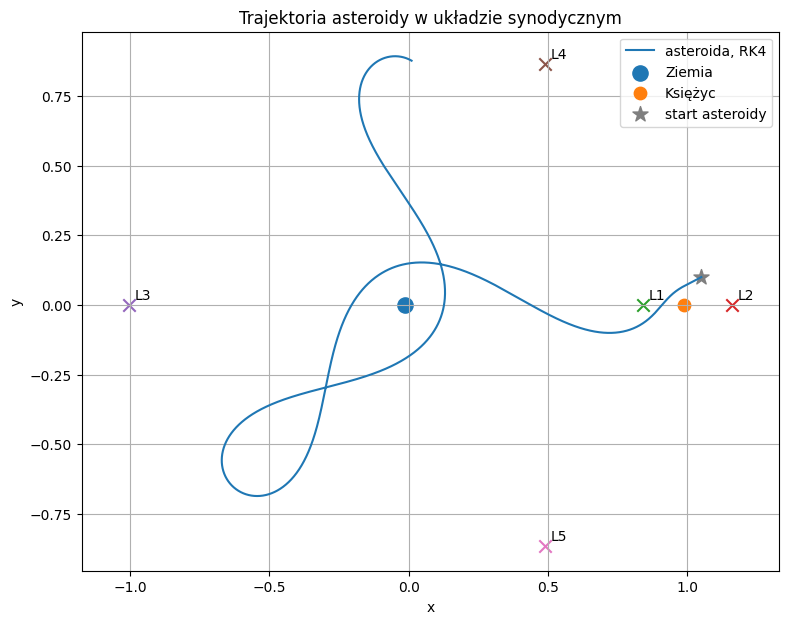

In [6]:
def lagrange_points(mu=mu):
    L1 = (1 - (mu/3)**(1/3), 0.0)
    L2 = (1 + (mu/3)**(1/3), 0.0)
    L3 = (-(1 + 5*mu/12), 0.0)
    L4 = (0.5 - mu,  np.sqrt(3)/2)
    L5 = (0.5 - mu, -np.sqrt(3)/2)
    return {"L1": L1, "L2": L2, "L3": L3, "L4": L4, "L5": L5}


LP = lagrange_points(mu)

earth_syn = np.array([-mu, 0.0])
moon_syn = np.array([1 - mu, 0.0])

Y_rk4 = solutions["RK4"]

plt.figure(figsize=(9, 7))
plt.plot(Y_rk4[:, 0], Y_rk4[:, 1], label="asteroida, RK4")
plt.scatter(*earth_syn, s=120, marker="o", label="Ziemia")
plt.scatter(*moon_syn, s=80, marker="o", label="Księżyc")

for label, (xL, yL) in LP.items():
    plt.scatter(xL, yL, marker="x", s=80)
    plt.text(xL + 0.02, yL + 0.02, label)

plt.scatter(Y0[0], Y0[1], marker="*", s=130, label="start asteroidy")

plt.axis("equal")
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajektoria asteroidy w układzie synodycznym")
plt.legend()
plt.show()

## Porównanie trajektorii metod

Poniższy wykres pozwala porównać trajektorie otrzymane czterema metodami.


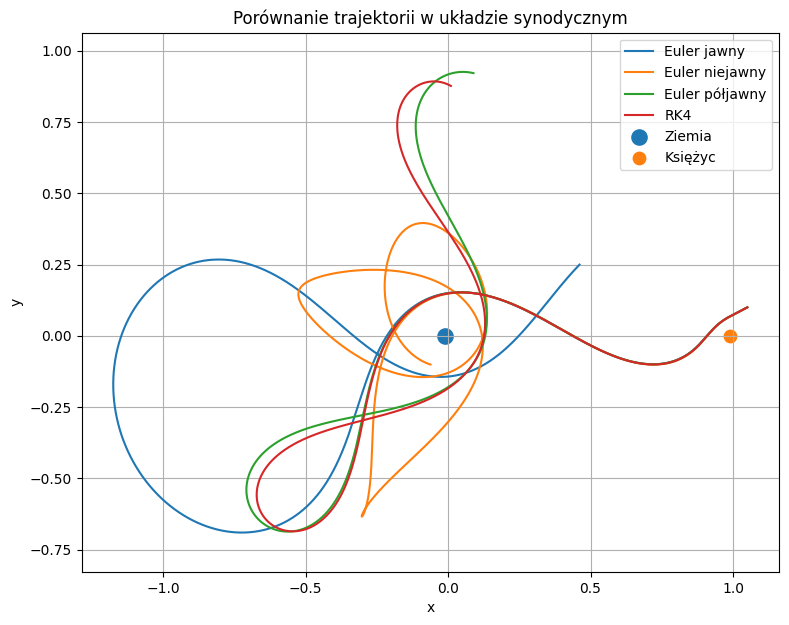

In [7]:
plt.figure(figsize=(9, 7))

for name, Y in solutions.items():
    plt.plot(Y[:, 0], Y[:, 1], label=name, linewidth=1.5)

plt.scatter(*earth_syn, s=120, marker="o", label="Ziemia")
plt.scatter(*moon_syn, s=80, marker="o", label="Księżyc")

plt.axis("equal")
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Porównanie trajektorii w układzie synodycznym")
plt.legend()
plt.show()

## Transformacja do układu inercjalnego

Dla położeń używamy wzoru:

\[
\begin{bmatrix}
X\\Y
\end{bmatrix}
=
\begin{bmatrix}
\cos t & -\sin t\\
\sin t & \cos t
\end{bmatrix}
\begin{bmatrix}
x\\y
\end{bmatrix}.
\]

Dla prędkości używamy wzoru z treści zadania.


In [8]:
def to_inertial_position(Y, t):
    """Transformacja położenia z układu synodycznego do inercjalnego."""
    x = Y[:, 0]
    y = Y[:, 1]
    c = np.cos(t)
    s = np.sin(t)

    X = c*x - s*y
    Yin = s*x + c*y
    return np.column_stack([X, Yin])


def fixed_point_to_inertial(point_xy, t):
    """Trajektoria w układzie inercjalnym punktu stałego w układzie synodycznym."""
    x = np.full_like(t, point_xy[0], dtype=float)
    y = np.full_like(t, point_xy[1], dtype=float)
    dummy = np.column_stack([x, y, np.zeros_like(t), np.zeros_like(t)])
    return to_inertial_position(dummy, t)


def to_inertial_velocity_formula_from_task(Y, t):
    """
    Transformacja prędkości zgodnie ze wzorem podanym w treści zadania:

    [U, V]^T =
        [[cos t, -sin t],
         [sin t,  cos t]] [u, v]^T
        +
        [[ sin t, cos t],
         [-cos t, sin t]] [x, y]^T
    """
    x = Y[:, 0]
    y = Y[:, 1]
    u = Y[:, 2]
    v = Y[:, 3]

    c = np.cos(t)
    s = np.sin(t)

    U = c*u - s*v + s*x + c*y
    V = s*u + c*v - c*x + s*y

    return np.column_stack([U, V])


asteroid_in = to_inertial_position(Y_rk4, t)
earth_in = fixed_point_to_inertial(earth_syn, t)
moon_in = fixed_point_to_inertial(moon_syn, t)

distance_asteroid_earth_in = np.linalg.norm(asteroid_in - earth_in, axis=1)
idx_min = np.argmin(distance_asteroid_earth_in)

print(f"Najbliższa odległość asteroidy od Ziemi, RK4: {distance_asteroid_earth_in[idx_min]:.8f}")
print(f"Czas najbliższego zbliżenia: t = {t[idx_min]:.5f}")

Najbliższa odległość asteroidy od Ziemi, RK4: 0.13453039
Czas najbliższego zbliżenia: t = 3.64400


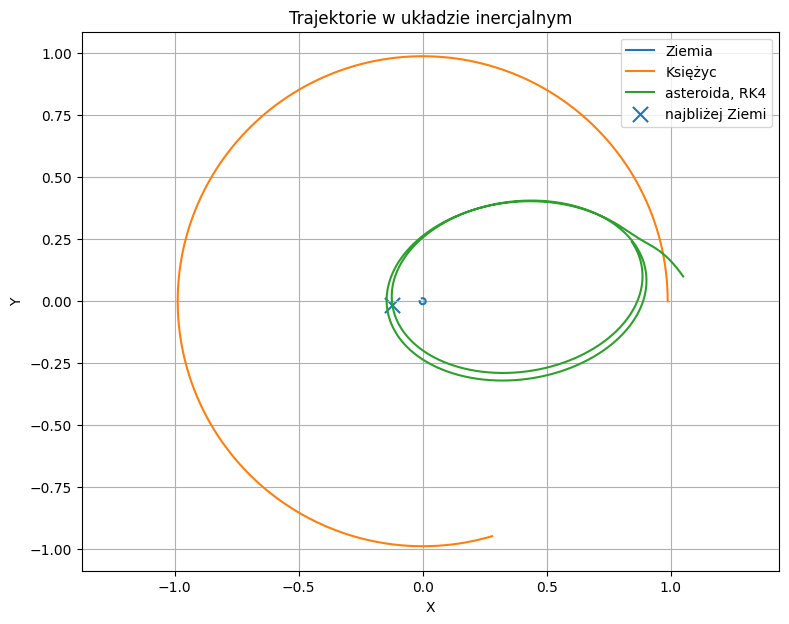

In [9]:
plt.figure(figsize=(9, 7))

plt.plot(earth_in[:, 0], earth_in[:, 1], label="Ziemia")
plt.plot(moon_in[:, 0], moon_in[:, 1], label="Księżyc")
plt.plot(asteroid_in[:, 0], asteroid_in[:, 1], label="asteroida, RK4")

plt.scatter(asteroid_in[idx_min, 0], asteroid_in[idx_min, 1],
            marker="x", s=120, label="najbliżej Ziemi")

plt.axis("equal")
plt.grid(True)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Trajektorie w układzie inercjalnym")
plt.legend()
plt.show()

## Prędkość asteroidy w układzie inercjalnym

Rysujemy wartość prędkości:

\[
\sqrt{U^2 + V^2}.
\]


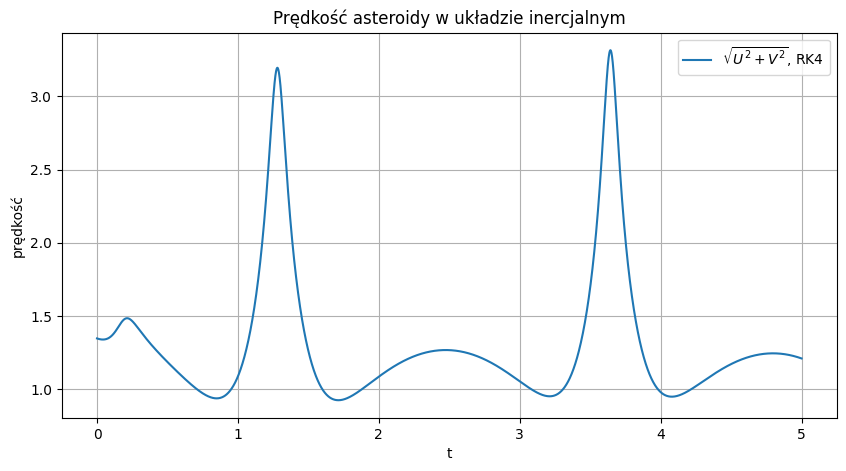

min prędkość inercjalna: 0.92409957
max prędkość inercjalna: 3.31533792


In [10]:
vel_in = to_inertial_velocity_formula_from_task(Y_rk4, t)
speed_in = np.linalg.norm(vel_in, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(t, speed_in, label=r"$\sqrt{U^2+V^2}$, RK4")
plt.grid(True)
plt.xlabel("t")
plt.ylabel("prędkość")
plt.title("Prędkość asteroidy w układzie inercjalnym")
plt.legend()
plt.show()

print(f"min prędkość inercjalna: {speed_in.min():.8f}")
print(f"max prędkość inercjalna: {speed_in.max():.8f}")

## Energie \(T\) i \(U\) dla wszystkich metod

Zgodnie z treścią zadania:

\[
T=\frac12(u^2+v^2),
\qquad
U=\frac12(x^2+y^2)+\frac{1-\mu}{r_1}+\frac{\mu}{r_2}.
\]


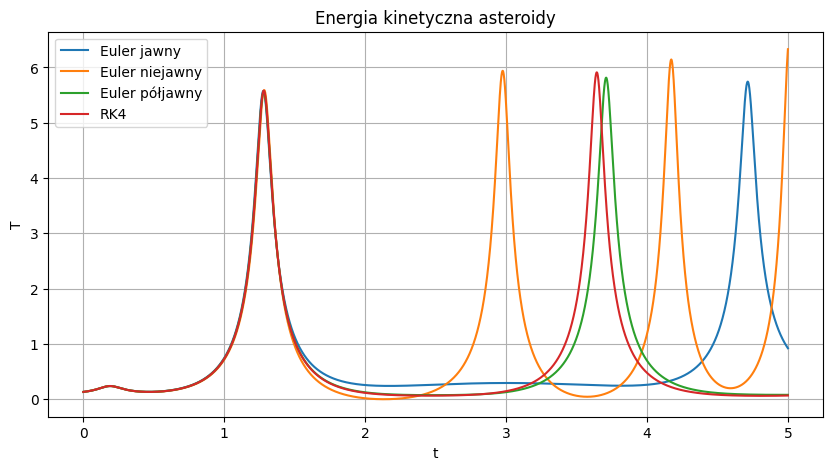

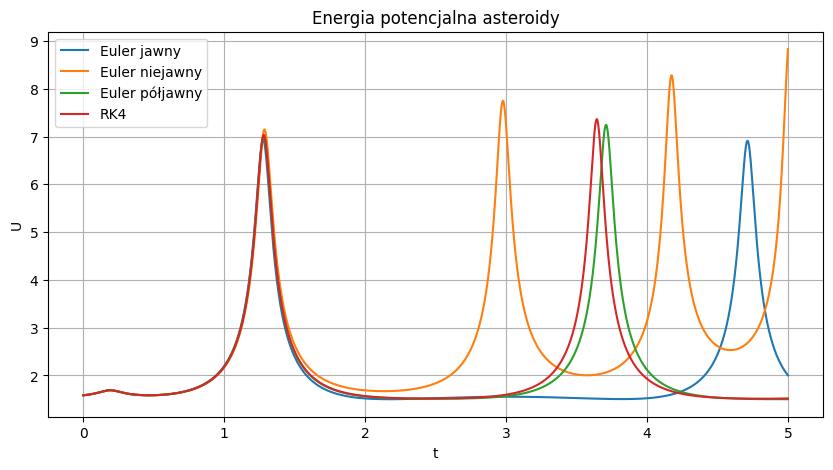

In [11]:
plt.figure(figsize=(10, 5))

for name, Y in solutions.items():
    plt.plot(t, kinetic_energy(Y), label=name)

plt.grid(True)
plt.xlabel("t")
plt.ylabel("T")
plt.title("Energia kinetyczna asteroidy")
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))

for name, Y in solutions.items():
    plt.plot(t, potential_energy(Y), label=name)

plt.grid(True)
plt.xlabel("t")
plt.ylabel("U")
plt.title("Energia potencjalna asteroidy")
plt.legend()
plt.show()

## Całka Jacobiego \(C\) dla wszystkich metod

\[
C=x^2+y^2+2\frac{1-\mu}{r_1}+2\frac{\mu}{r_2}-u^2-v^2.
\]

Dla dokładnego rozwiązania \(C\) powinno być stałe. Numerycznie porównujemy, jak bardzo \(C(t)\) odbiega od \(C(0)\).


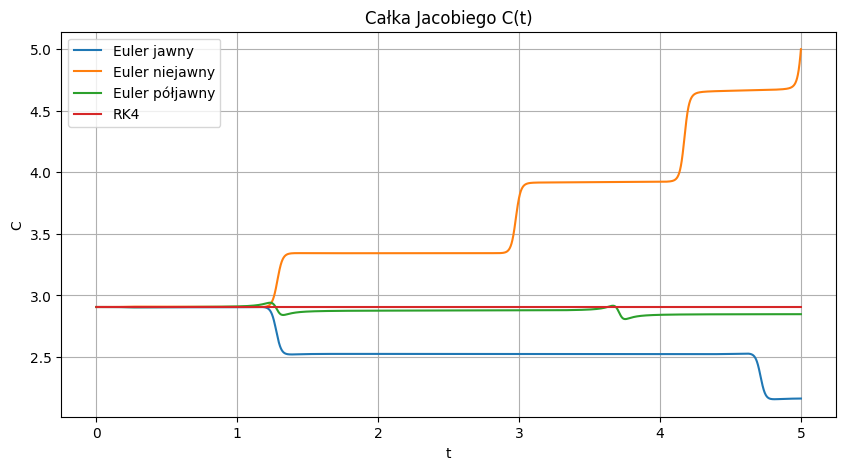

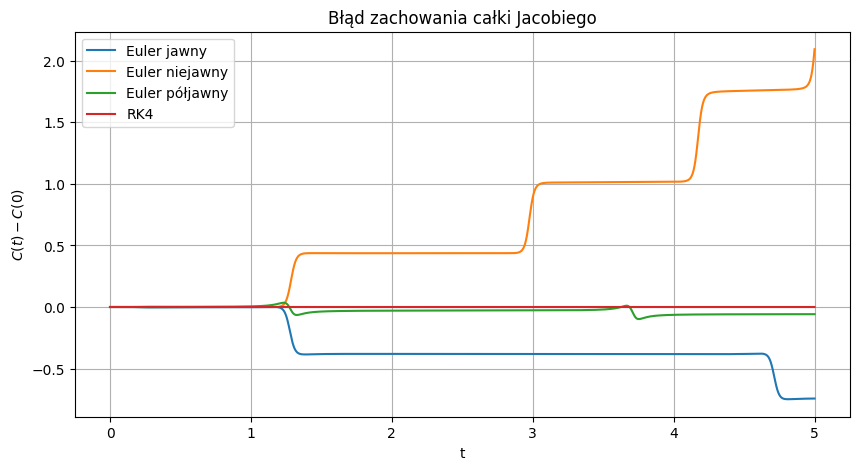

,metoda,C(0),C(t_end),max |C-C(0)|,"min r1, odległość od Ziemi",czas min r1,"min r2, odległość od Księżyca"
0,Euler jawny,2.9058,2.162558,7.488031e-01,0.142984,1.276,0.056898
1,Euler niejawny,2.9058,4.998950,2.093149e+00,0.112121,5.000,0.056548
2,Euler półjawny,2.9058,2.847473,9.805089e-02,0.136743,3.709,0.056809
3,RK4,2.9058,2.905800,7.868957e-09,0.134530,3.644,0.056726


In [12]:
plt.figure(figsize=(10, 5))

for name, Y in solutions.items():
    C = jacobi_constant(Y)
    plt.plot(t, C, label=name)

plt.grid(True)
plt.xlabel("t")
plt.ylabel("C")
plt.title("Całka Jacobiego C(t)")
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))

for name, Y in solutions.items():
    C = jacobi_constant(Y)
    plt.plot(t, C - C[0], label=name)

plt.grid(True)
plt.xlabel("t")
plt.ylabel(r"$C(t)-C(0)$")
plt.title("Błąd zachowania całki Jacobiego")
plt.legend()
plt.show()

summary

## Wniosek do sprawozdania

Typowo RK4 najlepiej zachowuje całkę Jacobiego dla danego kroku \(h\), natomiast jawny Euler szybko akumuluje błąd. Metody Eulera pierwszego rzędu mogą dawać znacząco inny obraz trajektorii i energii, szczególnie w pobliżu małych odległości od masywnych ciał.

W sprawozdaniu warto podać:

- użyty krok \(h\),
- najbliższą odległość asteroidy od Ziemi,
- wykresy trajektorii,
- porównanie \(C(t)-C(0)\) dla metod.
